# 📊 Customer Churn Analysis
**Author:** Jane Doe  
**Date:** July 2026

## 1. Project Objective
This notebook analyzes customer data to identify the primary drivers of subscription cancellations. Our goal is to build a predictive model to flag at-risk users.

---

## 2. Data Cleaning
In this section, we import the raw CSV, check for missing values, and convert categorical features into numerical formats.

* **Note:** Rows with missing `Signup_Date` values will be dropped.


In [6]:
%pip install pandas
import pandas as pd
%pip install matplotlib seaborn
import matplotlib.pyplot as plt
import seaborn as sns

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [7]:
data_url = "https://raw.githubusercontent.com/deepchem/deepchem/master/datasets/delaney-processed.csv"
df = pd.read_csv(data_url)
df.head()

,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles
0,Amigdalin,-0.974,1,457.432,7,3,7,202.32,-0.77,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...
1,Fenfuram,-2.885,1,201.225,1,2,2,42.24,-3.30,Cc1occc1C(=O)Nc2ccccc2
2,citral,-2.579,1,152.237,0,0,4,17.07,-2.06,CC(C)=CCCC(C)=CC(=O)
3,Picene,-6.618,2,278.354,0,5,0,0.00,-7.87,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43
4,Thiophene,-2.232,2,84.143,0,1,0,0.00,-1.33,c1ccsc1


In [8]:
correlation = df['Molecular Weight'].corr(df['measured log solubility in mols per litre'])
print(f"Correlation coefficient between Molecular Weight and Solubility: {correlation:.2f}")

Correlation coefficient between Molecular Weight and Solubility: -0.64


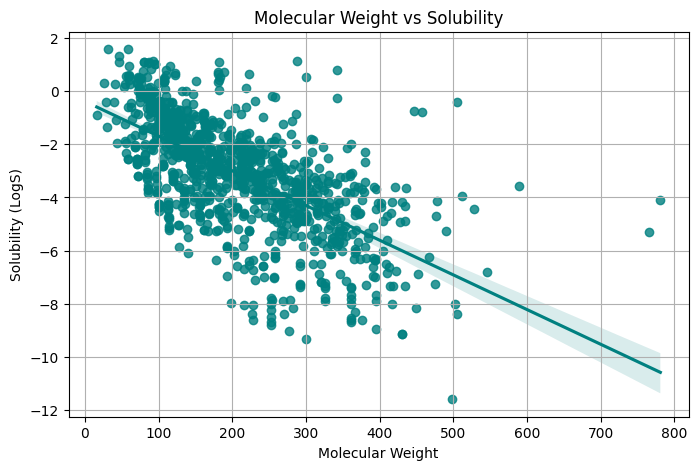

In [9]:
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='Molecular Weight', y='measured log solubility in mols per litre', color='teal')

plt.title('Molecular Weight vs Solubility')
plt.xlabel('Molecular Weight')
plt.ylabel('Solubility (LogS)')
plt.grid(True)
plt.show()

In [10]:
%pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [12]:
X = df[['Molecular Weight']]
y = df['measured log solubility in mols per litre']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [14]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("--- Machine Learning Model Evaluation ---")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2 Score): {r2:.2f}")
print(f"Model Equation: Solubility = ({model.coef_[0]:.4f} * Molecular Weight) + {model.intercept_:.2f}")

--- Machine Learning Model Evaluation ---
Root Mean Squared Error (RMSE): 1.71
R-squared (R2 Score): 0.38
Model Equation: Solubility = (-0.0129 * Molecular Weight) + -0.40


Selected numeric features:
['ESOL predicted log solubility in mols per litre', 'Minimum Degree', 'Molecular Weight', 'Number of H-Bond Donors', 'Number of Rings', 'Number of Rotatable Bonds', 'Polar Surface Area']

--- Advanced Model Performance (Random Forest) ---
Improved R2 Score: 0.90
Improved RMSE: 0.67


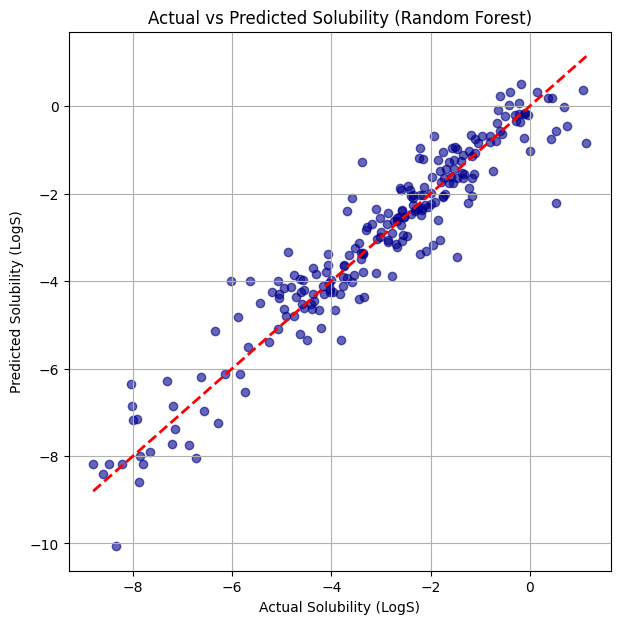

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

data_url = "https://raw.githubusercontent.com/deepchem/deepchem/master/datasets/delaney-processed.csv"
df = pd.read_csv(data_url)
target_col = 'measured log solubility in mols per litre'
y = df[target_col]
X_numeric = df.select_dtypes(include=[np.number]).drop(columns=[target_col])

print("Selected numeric features:")
print(X_numeric.columns.tolist())

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_numeric, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_m, y_train_m)

y_pred_rf = rf_model.predict(X_test_m)
rf_r2 = r2_score(y_test_m, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test_m, y_pred_rf))

print("\n--- Advanced Model Performance (Random Forest) ---")
print(f"Improved R2 Score: {rf_r2:.2f}")
print(f"Improved RMSE: {rf_rmse:.2f}")

plt.figure(figsize=(7, 7))
plt.scatter(y_test_m, y_pred_rf, alpha=0.6, color='darkblue')
plt.plot([y_test_m.min(), y_test_m.max()], [y_test_m.min(), y_test_m.max()], 'r--', lw=2)
plt.xlabel('Actual Solubility (LogS)')
plt.ylabel('Predicted Solubility (LogS)')
plt.title('Actual vs Predicted Solubility (Random Forest)')
plt.grid(True)
plt.show()